# The Efficient Frontier

## Imports

In [2]:
import pandas as pd
import numpy as np
import random
from matplotlib import pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from datetime import date
from dateutil.relativedelta import relativedelta

from trading_algos import optimization as tao
from trading_algos import datasets as tad
from trading_algos import plots as tap
from trading_algos import utils as tau
from trading_algos.utils import head_tail as ht

%load_ext autoreload
%autoreload 2

2026-06-11 22:02:11.598 | INFO     | trading_algos.config:<module>:11 - PROJ_ROOT path is: /home/jamie/code/JamieW365/trading_algos


## Load Data

In [40]:
# Choose a random selection of 5 stocks
random.seed(10)
n_assets = 5
tickers = tao.select_n(n_assets, tad.get_sp500_tickers())
df_stocks = tad.load_data(tickers=tickers, start_date='2020-01-01')
ht(df_stocks)

[*********************100%***********************]  5 of 5 completed


Price           Close                                                   \
Ticker            BHF         CVX        DDOG          DE           GS   
Date                                                                     
2020-01-02  39.220001   91.182571   36.700001  162.412338   201.232086   
2020-01-03  38.990002   90.867195   37.419998  161.209381   198.878952   
2020-01-06  37.959999   90.559311   39.900002  162.366455   200.914291   
2026-06-08  62.540001  189.240005  231.679993  573.659973  1045.000000   
2026-06-09  62.779999  186.759995  227.339996  577.330017  1032.010010   
2026-06-10  63.090000  189.800003  227.630005  560.049988  1001.289978   

Price            High                                                   ...  \
Ticker            BHF         CVX        DDOG          DE           GS  ...   
Date                                                                    ...   
2020-01-02  39.834999   91.332750   38.250000  162.430708   201.506893  ...   
2020-01-03  39.310001   92.151245   37.699001  161.402218   199.763506  ...   
2020-01-06  38.580002   91.362781   40.070000  162.430744   200.974413  ...   
2026-06-08  62.610001  191.029999  240.789993  592.609985  1063.180054  ...   
2026-06-09  62.919998  189.380005  236.830002  582.780029  1064.349976  ...   
2026-06-10  63.410000  192.690002  234.261002  577.460022  1036.310059  ...   

Price            Open                                                   \
Ticker            BHF         CVX        DDOG          DE           GS   
Date                                                                     
2020-01-02  39.779999   90.717007   38.220001  160.006370   198.380891   
2020-01-03  39.310001   91.445391   36.110001  159.978849   198.896132   
2020-01-06  38.270000   91.039891   37.509998  160.226790   197.461945   
2026-06-08  62.520000  188.699997  236.720001  585.799988  1052.780029   
2026-06-09  62.560001  188.500000  230.449997  577.630005  1061.790039   
2026-06-10  62.970001  189.190002  224.860001  577.460022  1028.349976   

Price        Volume                                       
Ticker          BHF       CVX     DDOG       DE       GS  
Date                                                      
2020-01-02   916900   5205000  1784200  1591100  3736300  
2020-01-03  1160800   6360900  1573200  1301100  2274500  
2020-01-06  1260200   9953000  5563200  1234200  3329300  
2026-06-08   539300   6113000  5632700  1476300  2326700  
2026-06-09   358200   8469900  4519300  1037300  2868500  
2026-06-10   590900  10041800  3525200  1112100  2287200  

[6 rows x 25 columns]

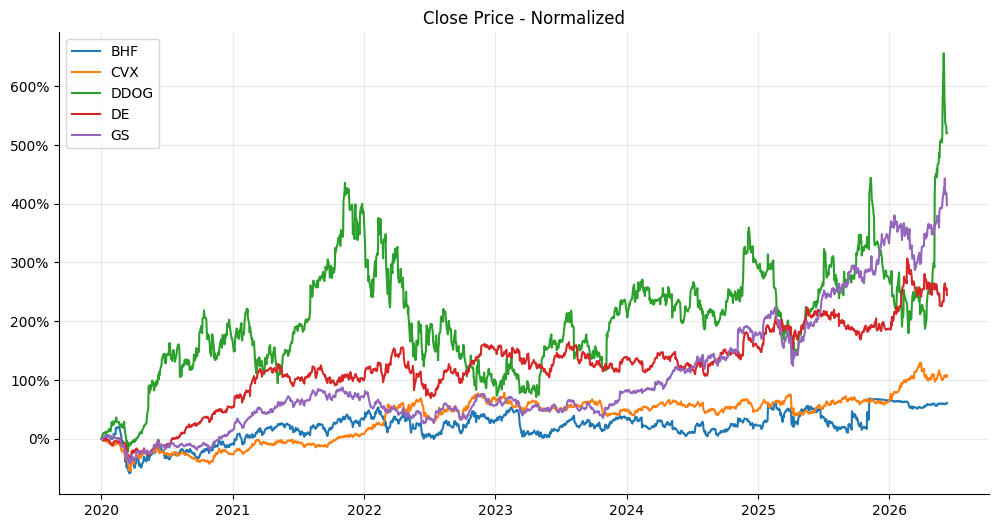

In [41]:
fig, ax = tap.trend(df_stocks, normalize=True)

## Compute Returns

In [42]:
log_prices = np.log(df_stocks.Close)

In [43]:
log_returns = (log_prices - log_prices.shift(1)).dropna()

In [47]:
mu = log_returns.mean() * 252
mu

Ticker
BHF     0.074084
CVX     0.114250
DDOG    0.284407
DE      0.192918
GS      0.250065
dtype: float64

In [48]:
cov = log_returns.cov() * 252
cov

Ticker,BHF,CVX,DDOG,DE,GS
Ticker,,,,,
BHF,0.274191,0.097086,0.074519,0.086013,0.112249
CVX,0.097086,0.113917,0.024806,0.055622,0.058784
DDOG,0.074519,0.024806,0.342774,0.029858,0.049502
DE,0.086013,0.055622,0.029858,0.106600,0.058522
GS,0.112249,0.058784,0.049502,0.058522,0.107784


In [59]:
0.74084 * 0.274191 + 0.74084 * 0.113917 + 0.74084 * 0.342774 + 0.74084 * 0.106600 + 0.74084 * 0.107784

0.7002908634400001

In [57]:
cov @ mu

Ticker
BHF     0.097262
CVX     0.052693
DDOG    0.123981
DE      0.056418
GS      0.067354
dtype: float64

In [ ]:
def portfolio_returns(weights):
    return np.dot(weights, mu)

In [ ]:
def portfolio_volatility(weights):
    return np.sqrt(weights.T @ cov)